In [1]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.describe()


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
df.isnull().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df['type'].value_counts()


type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [9]:
df['release_year'].value_counts().sort_index()


release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

In [10]:
df.groupby('type')['release_year'].count()


type
Movie      6131
TV Show    2676
Name: release_year, dtype: int64

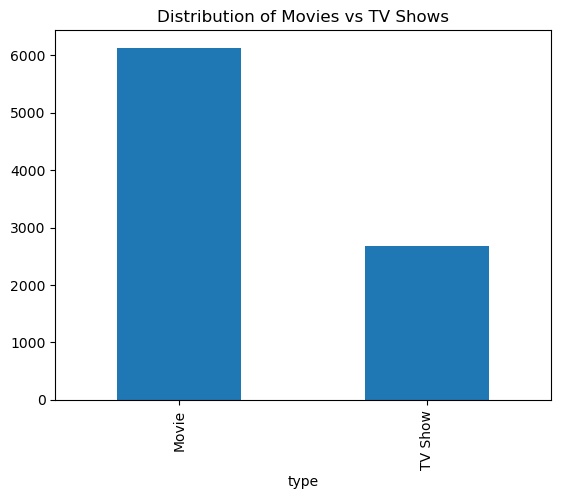

In [11]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar')
plt.title("Distribution of Movies vs TV Shows")
plt.show()


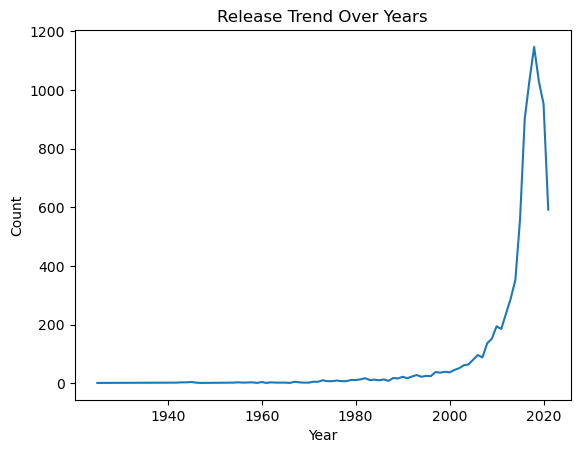

In [12]:
year_counts = df['release_year'].value_counts().sort_index()

year_counts.plot()
plt.title("Release Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


In [2]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [7]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [8]:
df['year_added'] = df['date_added'].dt.year

In [9]:
print(df['date_added'].isnull().sum())

df['year_added'] = df['date_added'].dt.year

98


<Axes: xlabel='year_added'>

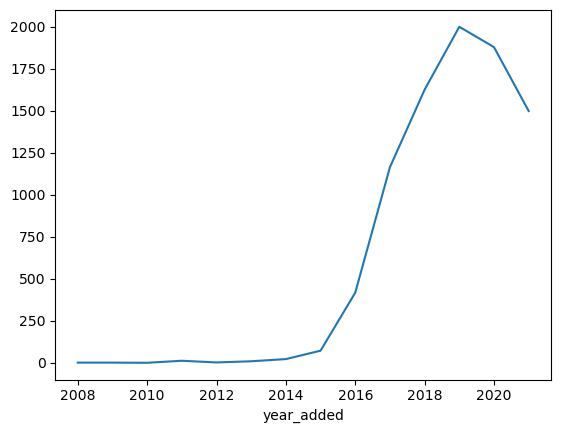

In [10]:
df['year_added'].value_counts().sort_index().plot()

<Axes: xlabel='release_year'>

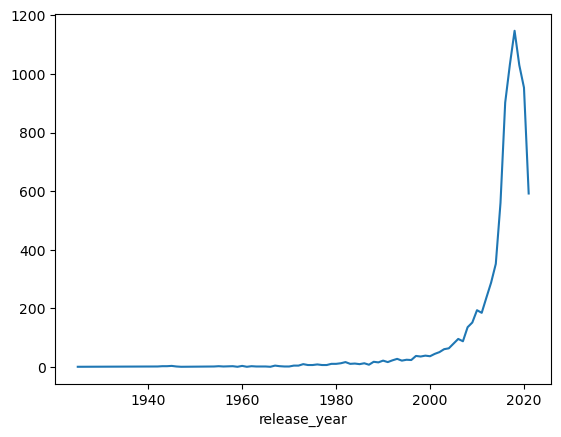

In [11]:
df['release_year'].value_counts().sort_index().plot()

<Axes: xlabel='year_added'>

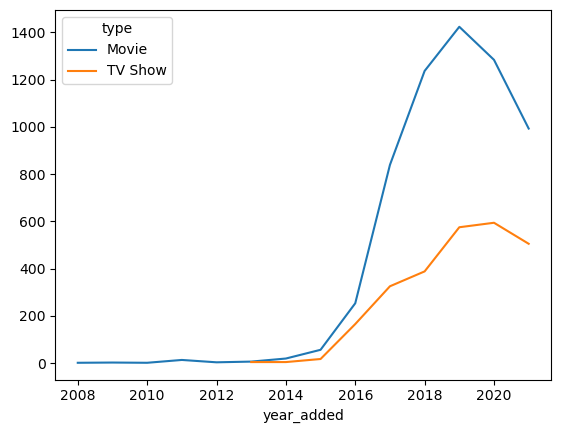

In [12]:
df.groupby(['year_added','type']).size().unstack().plot()

In [13]:
df['country'].value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [14]:
## Key Findings

1. Movie content increased rapidly after 2015.
2. TV Shows also grew, but at a slower rate.
3. The peak year appears around 2019.
4. United States dominates the content production.
5. India is the second largest contributor.


SyntaxError: invalid syntax (3388721650.py, line 3)

<Axes: xlabel='year_added'>

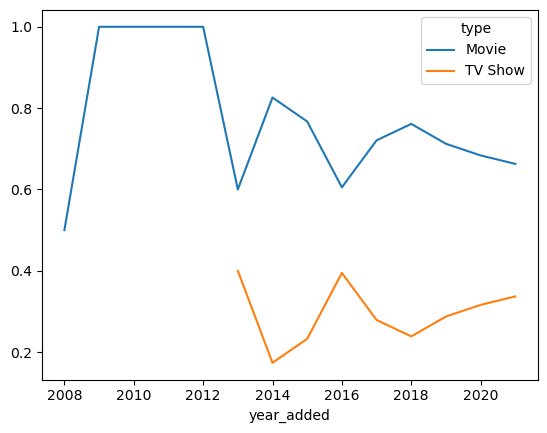

In [15]:
df.groupby(['year_added','type']).size().unstack().div(
    df.groupby('year_added').size(), axis=0
).plot()